# The muni funds everyone dumps in December — and buys back in January 🏛️
### Tax-loss season in municipal-bond closed-end funds, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Buy Dec-15, not Jan-15?: Mixed](https://img.shields.io/badge/Buy_Dec--15%2C_not_Jan--15%3F-Mixed-8b949e?style=flat-square)

Here's a corner of the market almost nobody looks at: **municipal-bond closed-end funds** — little listed funds that own tax-free city and state bonds. Their owners are almost all **ordinary taxable households** (the tax-free coupon is worthless to pension funds and IRAs). The story, from a 2006 *Journal of Finance* paper: every **December**, those households sell their losers to harvest a tax deduction. In a fund this small and retail-owned, that selling knocks the **price** down even though the bonds inside barely move. Then in **January** the sellers come back — and the price snaps back up.

A predictable dump, a predictable rebound, on a fixed calendar. Sounds too easy. Is it real?

> 📓 **Plain-language layer.** Want the *t*-stats, the exact placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We track **12 seasoned muni CEFs** against **MUB** (a muni ETF that trades at the value of its bonds). All 12 still trade today — that's **survivorship**, named openly. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from muni_cef_tax_loss import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    EX = data.monthly_excess(PX, bench=data.BENCH)        # MUB-excess panel (2007-10 ->)
    EX2 = data.monthly_excess(PX, bench=data.ALT_BENCH)   # VWLTX-excess panel (2000 ->)
    WT = st.winter_table(EX)
    WT2 = st.winter_table(EX2)
else:
    PX = EX = EX2 = WT = WT2 = None
print("real muni-CEF cache present:", HAVE_REAL,
      "| MUB-excess months:", (0 if EX is None else len(EX)),
      "| winters:", (0 if WT is None else len(WT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-03', 'end': '2026-06-30', 'rows': 6662, 'fingerprint': '5f10f3e3801d', 'n_funds': 12, 'months': 225, 'panel_start': '2007-10', 'n_winters': 19, 'n_winters_alt': 26, 'pooled': {'dec': -13.05, 'n_dec': 228, 'w_dec': -0.88, 'jan': 186.27, 'n_jan': 228, 'w_jan': 6.57, 'rest': 3.52, 'n_rest': 2244, 'w_jan_dec': 6.1}, 'dec_bps': -15.75, 't_dec': -0.33, 'jan_bps': 191.25, 't_jan': 2.27, 'hit_jan': 84.2, 'snap_bps': 207.0, 't_snap': 1.83, 'hit_snap': 73.7, 'snap_ac1': 0.069, 'placebo_rank': 4, 'placebo_p': 0.0303, 'placebo_floor': 0.0076, 'alt': {'jan': 180.34, 't_jan': 3.51, 'hit': 88.5, 'dec': 16.31, 't_dec': 0.49, 'snap': 164.03, 't_snap': 2.73, 'p': 0.0455, 'rank': 6}, 'fade': [('MUB 2007-2016', 326.63, 2.56, 10), ('MUB 2017-2025', 40.83, 0.45, 9), ('VWLTX 2000-2012', 274.92, 3.72, 13), ('VWLTX 2013-2025', 85.76, 1.34, 13)], 'fade_welch': 1.83, 'swap': [(5.0, 20, 171.25, 2.03, 84.2), (10.0, 40, 151.25, 1.79, 78.9), (25.0, 100, 91.25, 1.08, 73.7)], 'swap_gross': 191.25, 'dec15': 267.92, 'jan15': 33.46, 'diff': 234.45, 't_diff': 1.78, 'hit_diff': 73.7, 'ex08': 114.21, 't_ex08': 2.02, 'n_ex08': 18, 'syn': [(0, 0, 24.8, 0.65, 22.2, 0.53, 0.2424), (100, 100, 124.8, 3.26, 222.2, 5.33, 0.0076)]}


real muni-CEF cache present: True | MUB-excess months: 225 | winters: 19


## The answer first

| Question | Answer |
|---|---|
| Do these funds really snap back in January? | **Yes.** The average January beats the muni market by about **+1.9%** — positive in **16 of 19** winters. That part clears our significance bar, on two different benchmarks. |
| Do they really *dump* in December? | **Not on the monthly chart.** December as a whole looks flat — because the dump *and* the start of the rebound both happen inside December and cancel out. The real action runs **mid-December to mid-January**. |
| Can you trade it? | **Barely.** A once-a-year swap (park in MUB, hold the funds for January) survives low costs — but these are tiny, thinly-traded funds, and the effect has **faded** since the paper was published (+0.4% a January in the last decade, roughly the cost of trading it). |
| When should you buy? | **Mid-December, not mid-January.** By Jan-15 the party is basically over (+0.3% left of a +2.7% move) — though 19 winters can't *prove* the Dec-15 entry beyond doubt. |

> The legend is **half true**: the January snap-back is real; the December calendar-month dump is a mirage of averaging; and the tradable version is thin, once-a-year, and fading.

## 1 · The claim

> *"Taxable investors sell their losing muni closed-end funds in December to book tax losses. The selling widens the funds' discounts. In January the money comes back and the discount snaps shut. Buy the dump, ride the snap-back."*

This isn't bar-room folklore — it's **Starks, Yong & Zheng (2006), *Tax-Loss Selling and the January Effect: Evidence from Municipal Bond Closed-End Funds***, in the *Journal of Finance*. Muni CEFs are the cleanest possible laboratory: their owners are almost 100% taxable retail investors, so if tax-loss selling moves prices anywhere, it's here.

It's also the **seasonal cousin** of a trade we've already audited: [study 367](../../367-closed-end-fund-discount/README.md) showed that buying CEFs at wide **discounts** pays (the *level* edge). This study asks about the **calendar**: does the discount predictably widen in December and close in January?

## 2 · So what?

If true, this is about as honest as an anomaly gets: a **known cause** (the tax code's December 31 deadline), a **known victim** (a fund too small and retail-owned for professionals to bother correcting), and a **fixed calendar** anyone can act on. If false — or dead since publication — it's a perfect specimen of how a real paper becomes a zombie trade.

**How we see the discount without NAV data:** we measure each fund's monthly return *minus* MUB's. MUB trades at the value of its bonds, so when a fund's price lags MUB, its discount is widening; when it beats MUB, the discount is snapping shut. Total-return on both sides, so the funds' fat monthly payouts don't pollute anything.

## 3 · How would we even know?

- **12 seasoned muni CEFs** (Nuveen, BlackRock, Eaton Vance, Invesco, Western Asset), daily total-return prices 2000-01-03 → 2026-06-30.
- Each month, average the funds into **one basket number**: the basket's excess over MUB. One December + one January per winter = **19 winters** of evidence (a second benchmark, the Vanguard muni fund VWLTX, stretches it to **26**).
- Ask: is the average **January** excess reliably positive? Is **December** reliably negative? Could a *random* pair of months look this special? (We check every one of the 132 possible month-pairs.)
- Then the practical questions: does a once-a-year swap survive **costs**, and is **Dec-15 or Jan-15** the right day to buy?

## 4 · The teardown — let's actually look

**The whole year at a glance.** Average basket excess over MUB, month by month. If the tax-loss story is real, January should tower over everything.

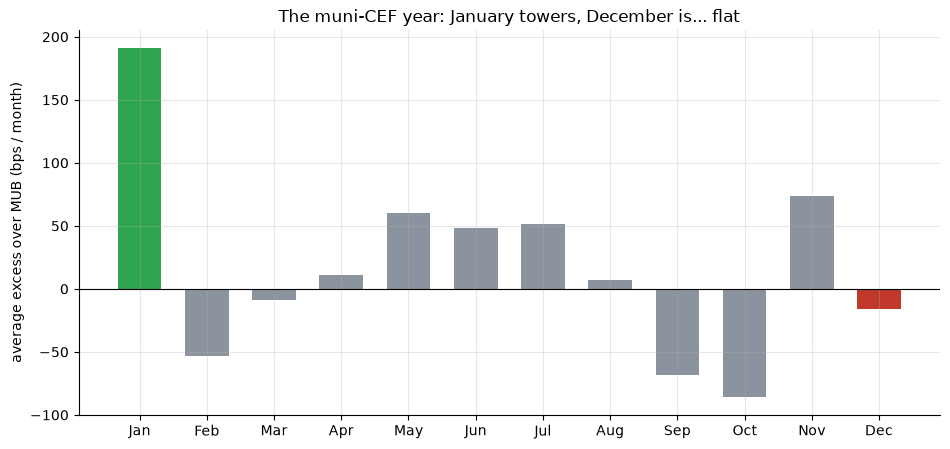

January: 191.2 bps   December: -15.7 bps


In [2]:
if HAVE_REAL:
    mu = st.seasonal_means(EX) * 1e4
    vals = [float(mu.get(m, np.nan)) for m in range(1, 13)]
else:
    vals = [191.2, -53.4, -9.0, 11.2, 60.2, 48.7, 51.5, 7.1, -68.6, -86.1, 73.8, -15.7]
names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = [GREEN] + [GREY]*10 + [RED]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(names, vals, color=colors, width=.65)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average excess over MUB (bps / month)')
ax.set_title('The muni-CEF year: January towers, December is... flat')
plt.tight_layout(); plt.show()
print('January:', round(vals[0],1), 'bps   December:', round(vals[11],1), 'bps')

**January is the outlier of the whole year**: **+191 bps** over the muni market on average, positive in **16 of 19** winters. But look at December (red): **-16 bps** — basically zero. The "December dump" doesn't show up as a bad *calendar month*. Hold that thought — the third chart explains why.

> 🔬 **For the quants:** one observation per winter, one-sample *t* = 2.27 on January; the Dec→Jan contrast ranks **4ᵗʰ of 132** possible month-pairs (exact *p* = 0.030); the longer VWLTX tape gives *t* = 3.51 over 26 winters.

**Winter by winter.** One bar per winter: the basket's January excess over MUB. A real seasonal should be *reliably* positive, not one lucky year.

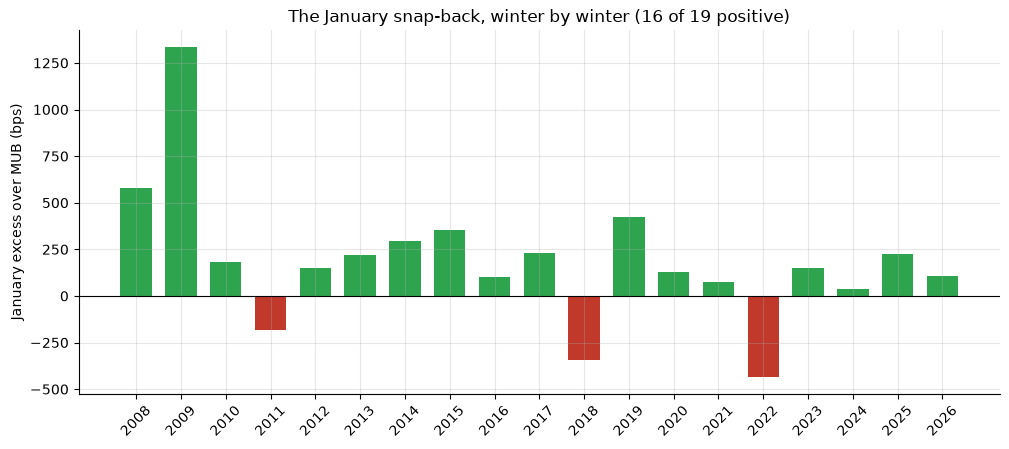

mean +191.2 bps   positive in 16 of 19 winters


In [3]:
if HAVE_REAL:
    yrs = [str(y+1) for y in WT.index]
    jans = (WT['jan'] * 1e4).values
else:
    yrs = [str(2008+i) for i in range(19)]; jans = np.full(19, R['jan_bps'])
fig, ax = plt.subplots(figsize=(10.2, 4.6))
ax.bar(yrs, jans, color=[GREEN if v > 0 else RED for v in jans], width=.7)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('January excess over MUB (bps)')
ax.set_title('The January snap-back, winter by winter (16 of 19 positive)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(f'mean {jans.mean():+.1f} bps   positive in {(jans>0).sum()} of {len(jans)} winters')

Green in **84%** of winters. But notice the *sizes*: the monsters are 2009 and the early 2010s; the last decade is mostly small bars. The effect was published in 2006 — and like most published anomalies, it has **faded**: post-2016 the average January is only **+41 bps**, roughly what the trade costs to execute.

**When exactly does the money move?** We race two buyers: one buys the funds on **Dec-15** (into the dump), one waits until **Jan-15**. Both sell at the end of February. The gap between them is the payoff earned *between* mid-December and mid-January.

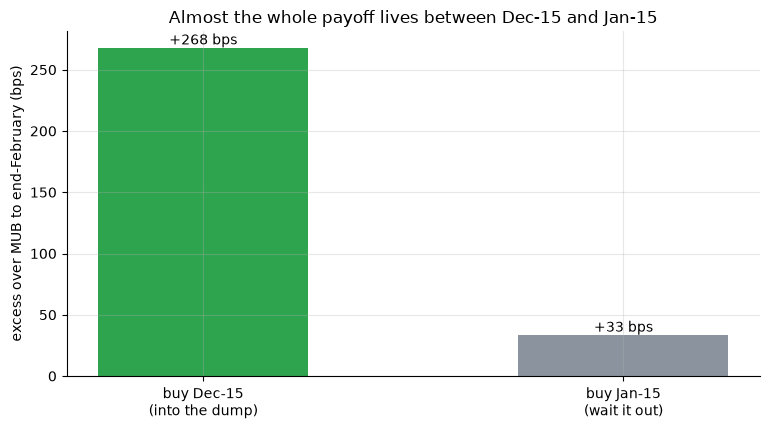

Dec-15 entry +267.9 bps   Jan-15 entry +33.5 bps   gap +234.5 bps


In [4]:
if HAVE_REAL:
    dj = st.dec15_vs_jan15(PX, data.BENCH, data.FUNDS)
    a, b = dj['winA_dec15'].mean()*1e4, dj['winB_jan15'].mean()*1e4
else:
    a, b = R['dec15'], R['jan15']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['buy Dec-15\n(into the dump)', 'buy Jan-15\n(wait it out)'], [a, b],
       color=[GREEN, GREY], width=.5)
for i, v in enumerate([a, b]): ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom')
ax.set_ylabel('excess over MUB to end-February (bps)')
ax.set_title('Almost the whole payoff lives between Dec-15 and Jan-15')
plt.tight_layout(); plt.show()
print(f'Dec-15 entry {a:+.1f} bps   Jan-15 entry {b:+.1f} bps   gap {a-b:+.1f} bps')

**There's the missing December dump.** The Dec-15 buyer earns **+268 bps**; the Jan-15 buyer only **+33 bps**. The dump happens mid-December, the snap-back starts *before* year-end — so the December *calendar month* nets out to zero while the mid-Dec→mid-Jan window carries everything. That's the actionable version: **if you play this at all, you buy into the December selling, not after New Year**. (One honest caveat: a chunk of that average is the crazy 2008 winter; strip it out and the gap is +114 bps — right at the edge of what 18 winters can prove.)

## 5 · The verdict

- **Signal — Mixed.** The **January snap-back is real**: +191 bps over the muni market, 84% of winters positive, significant on two benchmarks. The **December-month dump is not there** — it hides inside the month and cancels out.
- **Tradability — Fragile.** A once-a-year MUB→funds→MUB swap survives *low* costs (net +171 bps/winter at 5 bps a leg) but these are tiny, thin funds, and the last decade's payoff (~+41 bps) is about what the trading costs.
- **"Buy Dec-15, not Jan-15" — Mixed.** Directionally clear (the payoff is almost all pre-Jan-15), statistically not sealed in 19 winters.

## 6 · Going further 🚪

- **Why muni CEFs?** Because the owners are all taxable households — the tax-loss story has no other suspects here. That's why a 2006 *Journal of Finance* paper used them as the clean laboratory.
- **The cousin trade.** [Study 367](../../367-closed-end-fund-discount/README.md) tests the *level* version (buy wide discounts, any month). This was the *calendar* version. Same machinery — discounts set by retail flow — two different edges.
- **Build your own.** Swap in a different fund list, or move the entry day around Dec-15 — the engine (`muni_cef_tax_loss/`) exposes every knob.

*Think a once-a-year +1.9% gross seasonal on thin funds is your retirement plan? Check what's left after the fade and 4 trading legs — then we'll talk.*